In [ ]:
!pip install -q transformers
!pip install -q monai
!pip install roboflow
!pip install --upgrade --force-reinstall numpy==1.26.4

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from datasets import Dataset 
import os
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
from roboflow import Roboflow
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

rf = Roboflow(api_key=user_secrets.get_secret("ROBOFLOW_API_KEY"))
project = rf.workspace("visionary-lab").project("drywall-join-detect-0qk0k")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Drywall-Join-Detect-2 in yolov8:: 100%|██████████| 2048/2048 [00:00<00:00, 11721.86it/s]


In [3]:
project = rf.workspace("visionary-lab").project("cracks-3ii36-okj4b")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cracks-2 in yolov8:: 100%|██████████| 10743/10743 [00:01<00:00, 8898.12it/s]


In [4]:
tap_training_base = '/kaggle/working/Drywall-Join-Detect-2/train'
tap_validation_base = '/kaggle/working/Drywall-Join-Detect-2/valid'

crack_training_base = '/kaggle/working/cracks-2/train'
crack_validation_base = '/kaggle/working/cracks-2/valid'

tap_training_images_path = os.listdir('/kaggle/working/Drywall-Join-Detect-2/train/images')
tap_training_masks_path = os.listdir('/kaggle/working/Drywall-Join-Detect-2/train/labels')

crack_training_images_path = os.listdir('/kaggle/working/cracks-2/train/images')
crack_training_masks_path = os.listdir('/kaggle/working/cracks-2/train/labels')

tap_validation_images_path = os.listdir('/kaggle/working/Drywall-Join-Detect-2/valid/images')
tap_validation_masks_path = os.listdir('/kaggle/working/Drywall-Join-Detect-2/valid/labels')

crack_validation_images_path = os.listdir('/kaggle/working/cracks-2/valid/images')
crack_validation_masks_path = os.listdir('/kaggle/working/cracks-2/valid/labels')

In [5]:
def yolo_txt_to_mask(txt_path, img_width=352, img_height=352):
    mask = np.zeros((img_height, img_width), dtype=np.uint8)

    with open(txt_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue

        class_id, x_c, y_c, w, h = map(float, parts)

        # Convert normalized → pixel
        x_c *= img_width
        y_c *= img_height
        w *= img_width
        h *= img_height

        # Convert center → corners
        x1 = int(x_c - w / 2)
        y1 = int(y_c - h / 2)
        x2 = int(x_c + w / 2)
        y2 = int(y_c + h / 2)

        # Clip boundaries
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img_width, x2), min(img_height, y2)

        # Fill mask
        mask[y1:y2, x1:x2] = 1

    return mask

In [6]:
import cv2

def yolo_polygon_to_mask(txt_path, img_width=352, img_height=352):
    mask = np.zeros((img_height, img_width), dtype=np.uint8)

    with open(txt_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = list(map(float, line.strip().split()))
        
        class_id = int(parts[0])
        coords = parts[1:]

        # reshape into (N,2)
        points = np.array(coords).reshape(-1, 2)

        # scale to image size
        points[:, 0] *= img_width
        points[:, 1] *= img_height

        points = points.astype(np.int32)

        # draw filled polygon
        cv2.fillPoly(mask, [points], 1)

    return mask

In [7]:
tap_training_images = [Image.open(os.path.join(tap_training_base, 'images', path)) for path in tap_training_images_path]
tap_training_masks = [yolo_txt_to_mask(os.path.join(tap_training_base, 'labels', path.rsplit('.', 1)[0]+'.txt')) for path in tap_training_images_path]

crack_training_images = [Image.open(os.path.join(crack_training_base, 'images', path)) for path in crack_training_images_path]
crack_training_masks = [yolo_polygon_to_mask(os.path.join(crack_training_base, 'labels', path.rsplit('.', 1)[0]+'.txt')) for path in crack_training_images_path]

In [31]:
tap_validation_images = [Image.open(os.path.join(tap_validation_base, 'images', path)) for path in tap_validation_images_path]
tap_validation_masks = [yolo_txt_to_mask(os.path.join(tap_validation_base, 'labels', path.rsplit('.', 1)[0]+'.txt')) for path in tap_validation_images_path]

crack_validation_images = [Image.open(os.path.join(crack_validation_base, 'images', path)) for path in crack_validation_images_path]
crack_validation_masks = [yolo_polygon_to_mask(os.path.join(crack_validation_base, 'labels', path.rsplit('.', 1)[0]+'.txt')) for path in crack_validation_images_path]

In [8]:
import random

def sample_draw(images, masks, n =3):
    fig, axes = plt.subplots(n, 2, figsize=(8, 4*n))
    
    for i in range(n):
        idx = random.randint(0, len(images)-1)
        axes[i, 0].imshow(images[idx])
        axes[i, 0].axis('off')
        axes[i, 1].imshow(masks[idx])
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()

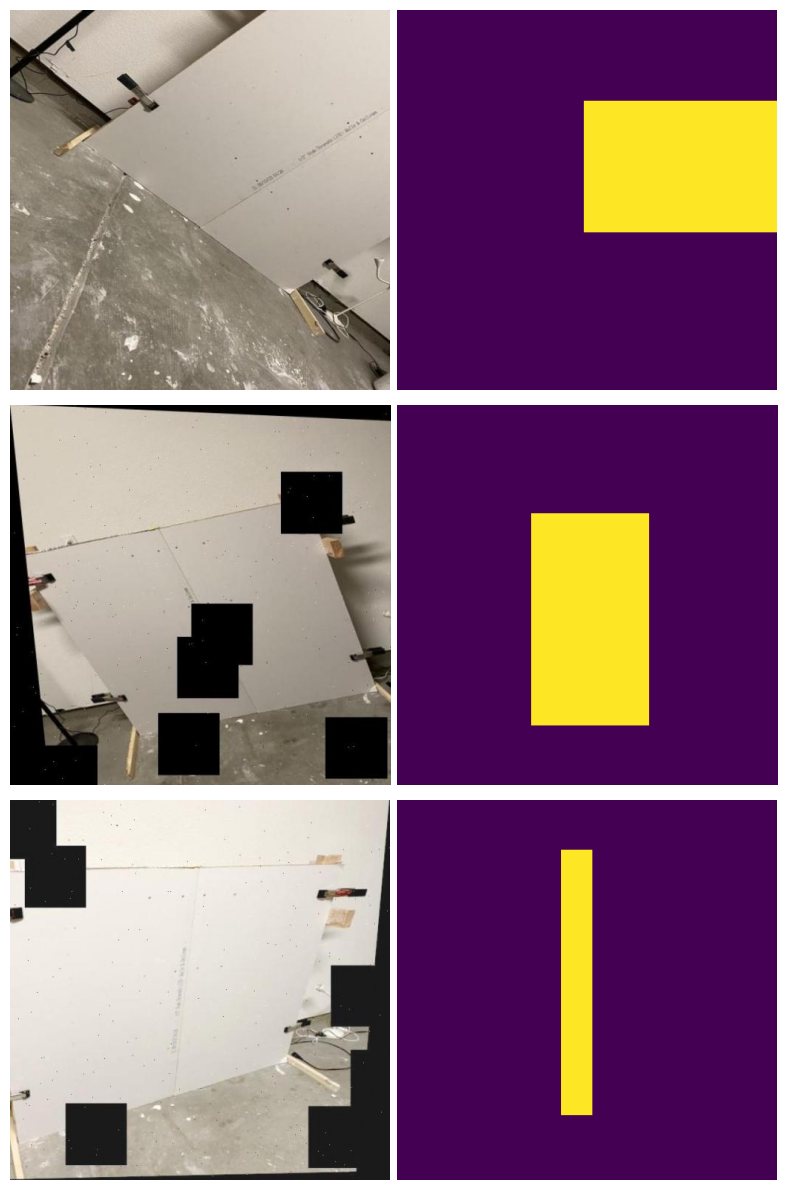

In [9]:
# draw sample images and masks
sample_draw(tap_training_images, tap_training_masks)

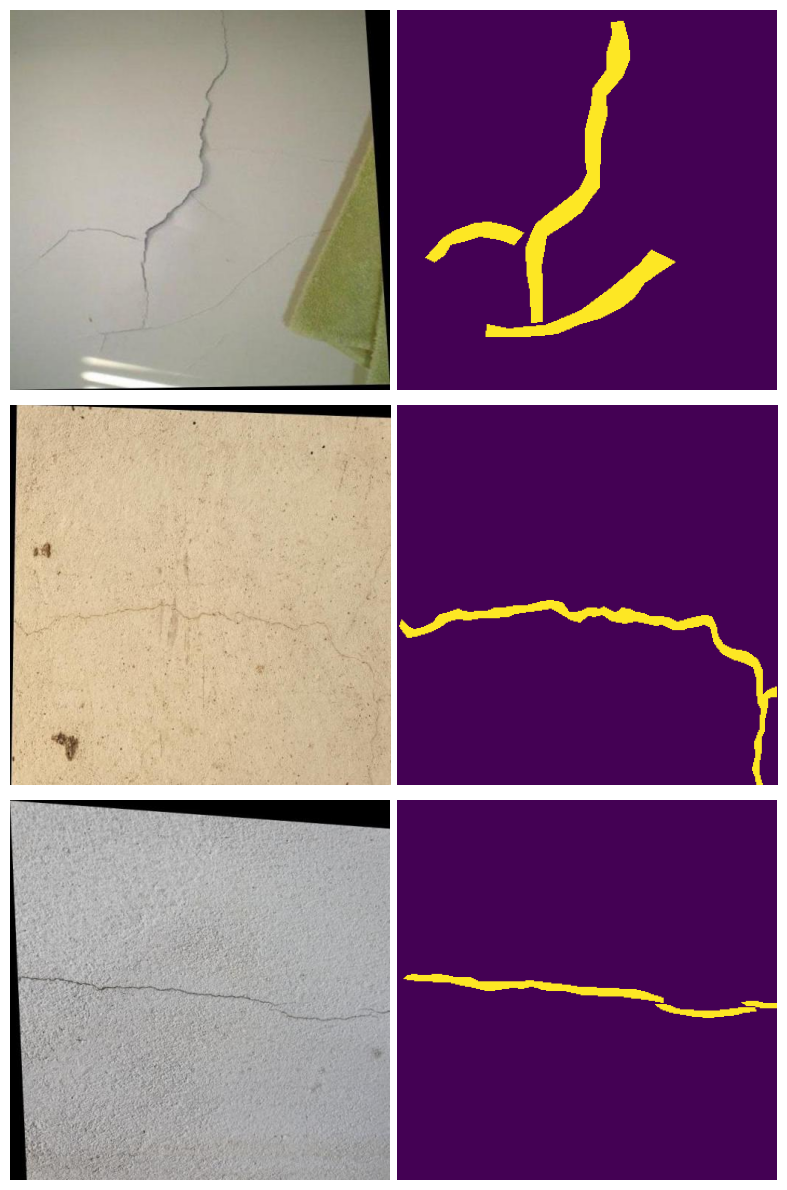

In [10]:
# draw sample images and masks
sample_draw(crack_training_images, crack_training_masks)

In [11]:
tapping_area_prompt_list = [
    "segment taping area",
    "segment joint tape",
    "segment drywall seam",
    "segment drywall joint",
    "segment wall seam",
    "segment taped joint",
    "segment drywall connection",
    "segment wall joint line",
    "segment seam line",
    "segment plaster seam",

    "segment drywall crack line",
    "segment joint compound area",
    "segment taped seam region",
    "segment drywall patch seam",
    "segment seam between panels",
    "segment drywall edge joint",
    "segment vertical seam",
    "segment horizontal seam",
    "segment wall panel joint",
    "segment drywall gap",

    "segment joint filler area",
    "segment taped crack",
    "segment finishing seam",
    "segment drywall joining line",
    "segment seam region on wall",
    "segment construction seam",
    "segment interior wall seam",
    "segment drywall finishing line",
    "segment seam under paint",
    "segment drywall board joint",

    "segment plaster joint",
    "segment seam repair area",
    "segment filled seam",
    "segment drywall finishing seam",
    "segment taped wall crack",
    "segment seam with compound",
    "segment drywall boundary line",
    "segment joint between drywall sheets",
    "segment seam in ceiling drywall",
    "segment wall board seam",

    "segment drywall seam defect",
    "segment seam with visible tape",
    "segment drywall tape line",
    "segment drywall seam under coating",
    "segment seam before painting",
    "segment seam after finishing",
    "segment drywall alignment joint",
    "segment seam in gypsum board",
    "segment drywall panel seam",
    "segment joint seam region"
]

In [12]:
crack_prompts = [
    "segment crack",
    "segment wall crack",
    "segment surface crack",
    "segment drywall crack",
    "segment wall damage",
    "segment crack line",
    "segment wall fracture",
    "segment surface fracture",
    "segment crack region",
    "segment damaged area",
    "segment wall defect",
    "segment crack on wall",
    "segment structural crack",
    "wall break",
    "segment crack pattern",
    "segment crack zone",
    "segment wall imperfection",
    "segment crack on surface",
    "segment damaged wall area",
    "segment fracture line",
    "segment wall crack line",
    "crack defect",
    "segment broken wall area",
    "segment surface damage",
    "segment crack boundary",
    "segment visible crack",
    "fine crack",
    "segment deep crack",
    "segment hairline crack",
    "wall seam crack",
    "segment crack in plaster",
    "segment crack in drywall",
    "segment cracked surface",
    "segment cracked wall",
    "segment crack edges",
    "crack region on wall",
    "segment wall crack defect",
    "segment structural damage area",
    "crack marks",
    "segment crack on building wall",
    "segment fracture on wall",
    "segment damaged surface area",
    "segment crack spread",
    "segment crack path",
    "segment crack formation",
    "segment crack cluster",
    "broken surface",
    "segment crack in structure",
    "wall surface crack",
    "segment crack area"
]

In [13]:
from datasets import Dataset

dataset_dict = {
    "images": tap_training_images + crack_training_images,
    "masks": tap_training_masks + crack_training_masks,
    "prompts": [random.choice(tapping_area_prompt_list) for _ in range(len(tap_training_images))] + [random.choice(crack_prompts) for _ in range(len(crack_training_images))],
    "types": [0]*len(tap_training_images) + [1]*len(crack_training_images)
}

dataset = Dataset.from_dict(dataset_dict)

In [67]:
val_tap_dataset_dict = {
    "images": tap_validation_images ,
    "masks": tap_validation_masks ,
    "prompts": [random.choice(tapping_area_prompt_list) for _ in range(len(tap_validation_images))],
    "types": [0]*len(tap_validation_images)
}

val_tap_dataset = Dataset.from_dict(val_tap_dataset_dict)

In [68]:
val_crack_dataset_dict = {
    "images": crack_validation_images,
    "masks":  crack_validation_masks,
    "prompts": [random.choice(crack_prompts) for _ in range(len(crack_validation_images))],
    "types": [1]*len(crack_validation_images)
}

val_crack_dataset = Dataset.from_dict(val_crack_dataset_dict)

In [14]:
from collections import Counter
import torch

labels = dataset_dict["types"]
class_counts = Counter(labels)

total = len(labels)

class_weights = {
    cls: total / count   
    for cls, count in class_counts.items()
}

In [15]:
sample_weights = torch.tensor([
    class_weights[label] for label in labels
], dtype=torch.float)

In [16]:
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [17]:
def collate_fn(batch):
    images = [item["images"] for item in batch]
    prompts = [item["prompts"] for item in batch]
    masks = [item["masks"] for item in batch]
    types = [item["types"] for item in batch]
    
    inputs = processor(
        images=images,
        text=prompts,
        padding=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}
    masks = [torch.tensor(m, dtype=torch.float32) for m in masks]
    inputs["ground_truth_mask"] = torch.stack(masks).to(device)
    inputs["types"] = torch.tensor(types, dtype=torch.long).to(device)
    
    return inputs

In [18]:
class CustomSamData(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __getitem__(self, idx):
        item = self.dataset[idx]
        return {
            "images": item["images"],
            "masks": item["masks"],
            "prompts": item["prompts"],
            "types": item["types"]
        }

    def __len__(self):
        return len(self.dataset)

In [71]:
from torch.utils.data import DataLoader

train_dataset = CustomSamData(dataset)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=20,
    sampler=sampler,
    collate_fn=collate_fn
)

In [72]:
validation_crack_dataset = CustomSamData(val_crack_dataset)
validation_crack_dataloader = DataLoader(
    validation_crack_dataset,
    batch_size=20,
    shuffle=True,
    collate_fn=collate_fn
)

In [73]:
validation_tap_dataset = CustomSamData(val_tap_dataset)
validation_tap_dataloader = DataLoader(
    validation_tap_dataset,
    batch_size=20,
    shuffle=True,
    collate_fn=collate_fn
)

In [106]:
import torch
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

processor = CLIPSegProcessor.from_pretrained("CIDAS/clipseg-rd64-refined", backend="torchvision")

In [107]:
# define model
model = CLIPSegForImageSegmentation.from_pretrained("CIDAS/clipseg-rd64-refined")
model.to(device)

Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

In [108]:
from torch.optim import Adam
import monai

# Initialize the optimizer and the loss function
optimizer = Adam(model.decoder.parameters(), lr=1e-5, weight_decay=0)

# #Try DiceFocalLoss, FocalLoss, DiceCELoss
# seg_loss = monai.losses.DiceCELoss(sigmoid=True, squared_pred=True, reduction='mean')

In [110]:
seg_loss = monai.losses.DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    lambda_dice=0.7,
    lambda_ce=0.3
)

In [111]:
# make sure we only compute gradients for mask decoder
for param in model.parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if name.startswith("decoder"):
        param.requires_grad = True

In [112]:
def evaluate_val_loss(model, val_loader):
    model.eval()
    val_losses = []

    with torch.no_grad():
        for batch in tqdm(val_loader):
            model_inputs = {
                k: v.to(device) for k, v in batch.items() if k not in ["ground_truth_mask", "types"]
            }
            ground_truth_masks = batch["ground_truth_mask"]

            outputs = model(**model_inputs)
            loss = seg_loss(outputs.logits, ground_truth_masks)

            val_losses.append(loss.item())

    return sum(val_losses) / len(val_losses)

In [113]:
def dice_score(preds, targets, eps=1e-6):
    with torch.no_grad():
        preds = torch.sigmoid(preds)
        preds = (preds > 0.5).float()
    
        if targets.dim() == 4:
            targets = targets.squeeze(1)
    
        if preds.dim() == 4:
            preds = preds.squeeze(1)
    
        intersection = (preds * targets).sum()
        union = preds.sum() + targets.sum()

    return (2 * intersection + eps) / (union + eps)

In [114]:
from tqdm import tqdm
from statistics import mean
import torch
from torch.amp import autocast, GradScaler

#Training loop
scaler = GradScaler("cuda")
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []
    epoch_dice = []
    
    for batch in tqdm(train_dataloader):
      # forward pass
      model_inputs = {k: v for k, v in batch.items() if k not in ["ground_truth_mask", "types"]}
      with autocast("cuda"):
          outputs = model(**model_inputs)
          predicted_masks = outputs.logits
          ground_truth_masks = batch["ground_truth_mask"].squeeze(1)
          loss = seg_loss(predicted_masks, ground_truth_masks)

      # backward pass (compute gradients of parameters w.r.t. loss)
      optimizer.zero_grad()
      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update()

      with torch.no_grad():
          epoch_losses.append(loss.item())
          epoch_dice.append(dice_score(predicted_masks, ground_truth_masks).item())
        
    print(f'EPOCH: {epoch}')
    print(f'TRAIN Loss: {mean(epoch_losses)}')
    print(f"TRAIN Dice: {mean(epoch_dice)}")

    tap_val_loss = evaluate_val_loss(model, validation_tap_dataloader)
    crack_val_loss = evaluate_val_loss(model, validation_crack_dataloader)

    print(f'VALIDATION TAP LOSS: {tap_val_loss}')
    print(f'VALIDATION CRACK LOSS: {crack_val_loss}')

100%|██████████| 300/300 [07:45<00:00,  1.55s/it]


EPOCH: 0
TRAIN Loss: 60.677745494842526
TRAIN Dice: 0.17259065551062425


100%|██████████| 11/11 [00:20<00:00,  1.84s/it]


VALIDATION TAP LOSS: 90.47446051510897
VALIDATION CRACK LOSS: 41.477115804498844


100%|██████████| 300/300 [07:40<00:00,  1.53s/it]


...

VALIDATION TAP LOSS: 89.64228820800781
VALIDATION CRACK LOSS: 26.92185861414129


100%|██████████| 300/300 [07:12<00:00,  1.44s/it]


EPOCH: 49
TRAIN Loss: 58.07228974024455
TRAIN Dice: 0.5355112134416898


100%|██████████| 11/11 [00:19<00:00,  1.73s/it]

VALIDATION TAP LOSS: 91.44818045876242
VALIDATION CRACK LOSS: 29.11714813926003


In [115]:
# Save the model's state dictionary to a file
torch.save(model.state_dict(), "Drywall-Crack-Tap-Segmentation-Model.pth")

In [ ]:
from transformers import CLIPSegForImageSegmentation

tuned_model = CLIPSegForImageSegmentation.from_pretrained(
    "CIDAS/clipseg-rd64-refined"
)

tuned_model.load_state_dict(torch.load("/kaggle/working/Drywall-Crack-Tap-Segmentation.pth"), strict=False)

In [116]:
model.to(device)

CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

In [117]:
model.eval()

CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

In [ ]:
tap_validation_images = [Image.open(os.path.join(tap_validation_base, 'images', path)) for path in tap_validation_images_path]
tap_validation_masks = [yolo_txt_to_mask(os.path.join(tap_validation_base, 'labels', path.rsplit('.', 1)[0]+'.txt')) for path in tap_validation_images_path]

crack_validation_images = [Image.open(os.path.join(crack_validation_base, 'images', path)) for path in crack_validation_images_path]
crack_validation_masks = [yolo_polygon_to_mask(os.path.join(crack_validation_base, 'labels', path.rsplit('.', 1)[0]+'.txt')) for path in crack_validation_images_path]

In [118]:
def predict(prompt, image):
    inputs = processor(
        images=image,
        text=prompt,
        padding=True,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    return (torch.sigmoid(model(**inputs).logits) > 0.5).float()

In [122]:
import random

def tap_sample_prediction_draw(n = 3):
    fig, axes = plt.subplots(n, 3, figsize=(8, 4*n))
    
    for i in range(n):
        idx = random.randint(0, len(tap_validation_images)-1)
        axes[i, 0].imshow(tap_validation_images[idx])
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(tap_validation_masks[idx])
        axes[i, 1].axis('off')

        predicted_mask = predict("segment tap area", tap_validation_images[idx])
        predicted_mask = predicted_mask.squeeze(0).detach().cpu().numpy()
        axes[i, 2].imshow(predicted_mask)
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

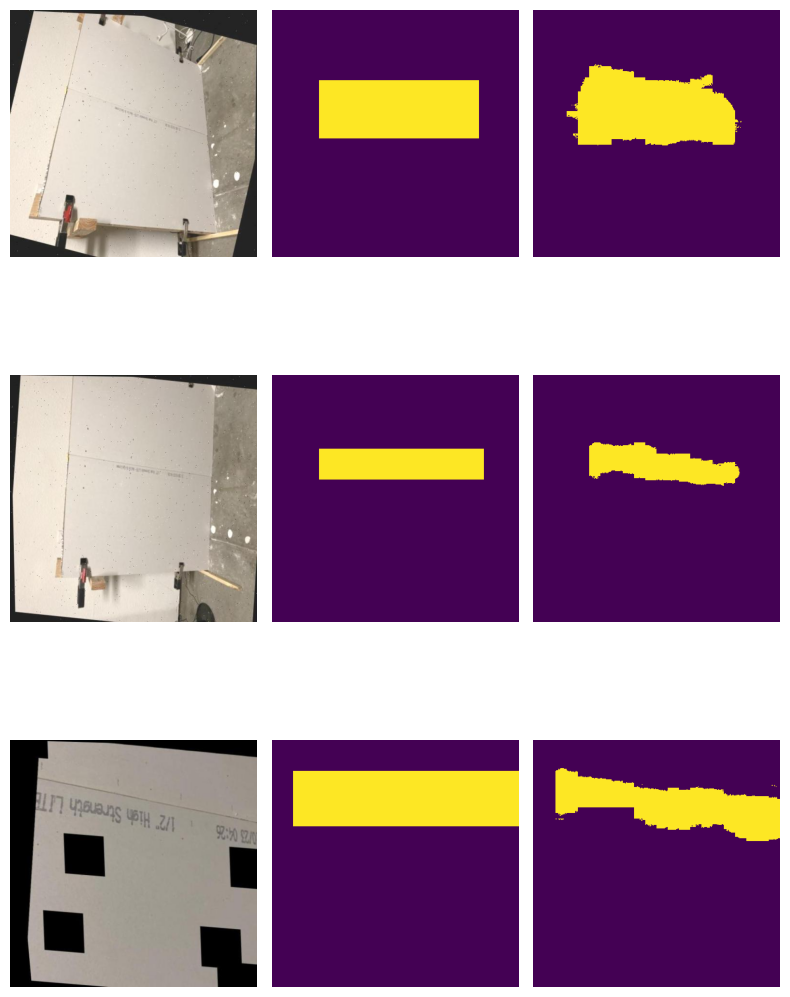

In [123]:
tap_sample_prediction_draw()

In [126]:
import random

def crack_sample_prediction_draw(n = 3):
    fig, axes = plt.subplots(n, 3, figsize=(8, 4*n))
    
    for i in range(n):
        idx = random.randint(0, len(crack_validation_images)-1)
        axes[i, 0].imshow(crack_validation_images[idx])
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(crack_validation_masks[idx])
        axes[i, 1].axis('off')

        predicted_mask = predict("segment crack area in wall", crack_validation_images[idx])
        predicted_mask = predicted_mask.squeeze(0).detach().cpu().numpy().astype(np.uint8) * 255
        axes[i, 2].imshow(predicted_mask)
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

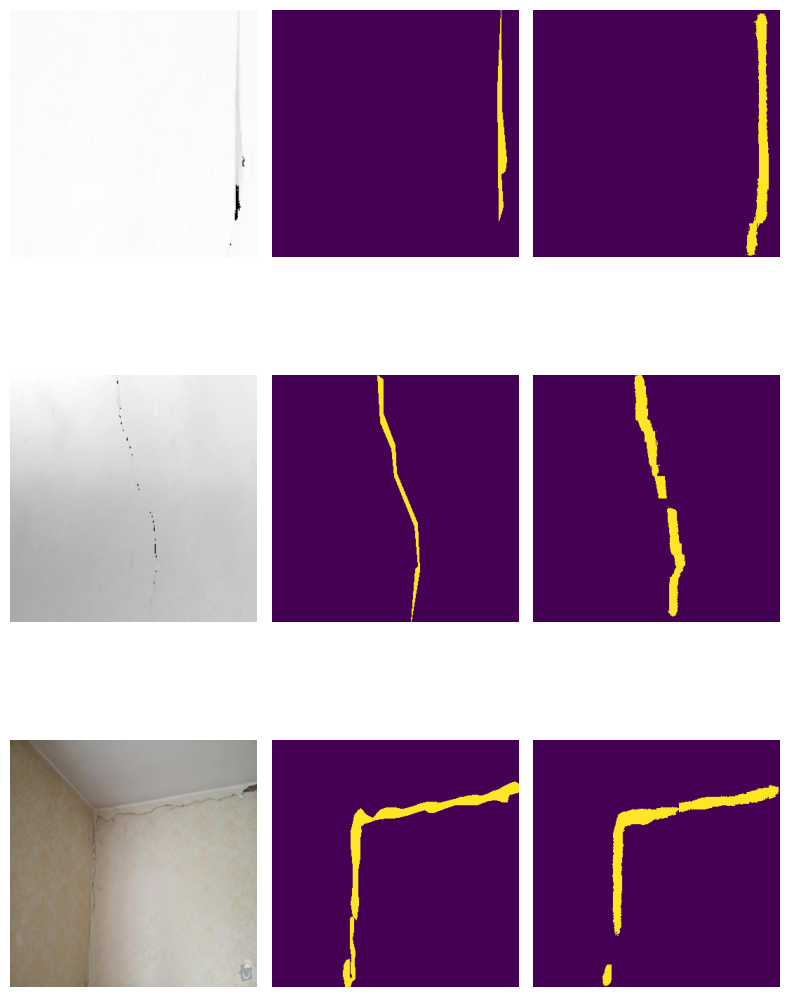

In [130]:
crack_sample_prediction_draw()

In [131]:
def dice_score(preds, targets, threshold=0.5, eps=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    intersection = (preds * targets).sum(dim=(1,2,3))
    total = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

    dice = (2 * intersection + eps) / (total + eps)
    return dice.mean()


In [132]:
def mean_iou(preds, targets, threshold=0.5, eps=1e-6):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    intersection = (preds * targets).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean()

In [133]:
def evaluate(loader):
    total_dice = 0
    total_dice = 0
    total_iou = 0
    count = 0
    
    with torch.no_grad():
        for batch in tqdm(loader):
            
            model_inputs = {k: v.to(device) for k, v in batch.items() if k != "ground_truth_mask"}
            ground_truth_masks = batch["ground_truth_mask"].unsqueeze(1).to(device)
    
            outputs = model(**model_inputs)
            predicted_masks = outputs.logits.unsqueeze(1)
    
            # compute metrics
            dice = dice_score(predicted_masks, ground_truth_masks)
            iou = mean_iou(predicted_masks, ground_truth_masks)
    
            total_dice += dice.item()
            total_iou += iou.item()
            count += 1
    
    print(f"Mean Dice: {total_dice / count:.4f}")
    print(f"Mean IoU: {total_iou / count:.4f}")
    return total_dice / count, total_iou / count


In [134]:
print("Evaluation on Tap data!")
tap_dice, tap_iou = evaluate(validation_tap_dataloader)

Evaluation on Tap data!


100%|██████████| 11/11 [00:19<00:00,  1.75s/it]

Mean Dice: 0.5110
Mean IoU: 0.3816


In [135]:
print("Evaluation on Crack data!")
crack_dice, crack_iou = evaluate(validation_crack_dataloader)

Evaluation on Crack data!


100%|██████████| 11/11 [00:19<00:00,  1.74s/it]

Mean Dice: 0.6328
Mean IoU: 0.4853
